# aeon-qc exploration

Interactive cells for testing QC metrics against benchmark datasets.
See `benchmarks.yaml` for dataset paths and time ranges (machine-readable).

In [37]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
from swc.aeon.qc import (
    heartbeat_gaps, heartbeat_duplicates,
    dropped_frames, frame_rate_stability, epoch_gaps,
    run_qc, save_results, generate_report,
    diagnose_devices, schema_from_filesystem,
)

## Configuration

Edit these values to point at the dataset you want to inspect. In the case that a bonsai crash occured, then continuing the experiment will produce a new data directory (a new epoch). In this case, your START and END times should cover both (or more) data epochs.

In [38]:
ROOT = r"Z:\aeon\data\raw\AEON3\social0.2"
START = pd.Timestamp("2024-01-31T11:00:00", tz="UTC")
END   = pd.Timestamp("2024-02-01T21:00:00", tz="UTC")

diag = diagnose_devices(ROOT, start=START, end=END)

# Three-way presence table
all_devices = (
    (diag["registry"] or set())
    | (diag["metadata"] or set())
    | diag["filesystem"]
)
registry_col = f"registry ({diag['registry_key'] or 'no match'})"
rows = []
for device in sorted(all_devices):
    rows.append({
        "device": device,
        registry_col: "Y" if diag["registry"] and device in diag["registry"] else "",
        "metadata.yml": ("N/A" if diag["metadata"] is None
                         else ("Y" if device in diag["metadata"] else "")),
        "filesystem": "Y" if device in diag["filesystem"] else "",
    })
diag_df = pd.DataFrame(rows).set_index("device")
display(diag_df)

# Use filesystem scan as the working schema so downstream cells only
# attempt devices that actually have data on disk.
SCHEMA = schema_from_filesystem(ROOT, start=START, end=END)

,registry (social02),metadata.yml,filesystem
device,,,
AudioAmbient,,Y,
CameraEast,Y,Y,
CameraNest,Y,Y,
CameraNorth,Y,Y,
CameraPatch1,Y,Y,
CameraPatch2,Y,Y,
CameraPatch3,Y,Y,
CameraSouth,Y,Y,
CameraTop,Y,Y,Y


## Dataset timestamp bounds

Reports the first and last recorded timestamp for each device stream within the selected window.
Useful for confirming when data acquisition ended or detecting devices that stopped early. Note that in the first seconds as devices are initializing, Bonsai may produce Harp sync errors that are spurious. These are real, but data is only logged based on the first common heartbeats recieved, so will not be logged

In [39]:
from swc.aeon.io import api as aeon_api
from swc.aeon.qc.report import iter_readers

rows = []
for device_name, reader in iter_readers(SCHEMA):
    try:
        df = aeon_api.load(ROOT, reader, start=START, end=END)
        first_ts = df.index.min() if not df.empty else None
        last_ts  = df.index.max() if not df.empty else None
    except Exception:
        first_ts = last_ts = None
    rows.append({"device": device_name, "first_timestamp": first_ts, "last_timestamp": last_ts})

ts_df = pd.DataFrame(rows).set_index("device").sort_values("last_timestamp", ascending=False)
display(ts_df)

,first_timestamp,last_timestamp
device,,
ClockSynchronizer.Heartbeat,2024-01-31 11:28:46+00:00,2024-02-01 20:48:56+00:00
Patch1.Heartbeat,2024-01-31 11:28:46+00:00,2024-02-01 20:48:56+00:00
Patch2.Heartbeat,2024-01-31 11:28:46+00:00,2024-02-01 20:48:56+00:00
Patch3.Heartbeat,2024-01-31 11:28:46+00:00,2024-02-01 20:48:56+00:00
VideoController.Heartbeat,2024-01-31 11:28:46+00:00,2024-02-01 20:48:55+00:00
CameraTop.Video,2024-01-31 11:28:45.543519974+00:00,2024-01-31 11:59:59.980000019+00:00
Metadata,NaT,NaT


## Epoch gaps

Detects gaps between consecutive Bonsai session starts within the `START`/`END` window.
`load()` assembles `Metadata.yml` timestamps across all epoch directories in that range. Note that if metadata.yml is not present, that epoch will not be found here.

In [40]:
epochs = epoch_gaps(ROOT, start=START, end=END)
n_gaps = int(epochs["gap_duration"].notna().sum())
print(f"{len(epochs)} epoch(s) in range, {n_gaps} inter-epoch gap(s)")
if not epochs.empty:
    if n_gaps > 0:
        real_gaps = epochs["gap_duration"].dropna()
        print(f"Shortest: {real_gaps.min()}, Longest: {real_gaps.max()}")
    display(epochs)

0 epoch(s) in range, 0 inter-epoch gap(s)


## Heartbeat gaps

Detects periods where a Harp device stops sending heartbeat events (~1 Hz).
A gap is flagged whenever the Harp `second` counter increments by more than 1 between
consecutive rows.

Returns a DataFrame indexed by gap-start time with `duration`, `n_missed`,
`second_before`, `second_after`, and `device` columns.

In [41]:
from swc.aeon.io.reader import Heartbeat as HeartbeatReader
from swc.aeon.qc.report import iter_readers

hb_devices = {name: reader for name, reader in iter_readers(SCHEMA)
              if isinstance(reader, HeartbeatReader)}

if not hb_devices:
    print("No Heartbeat devices found in this dataset")
else:
    print(f"Found {len(hb_devices)} heartbeat device(s): {list(hb_devices.keys())}\n")
    for device_name, hb_reader in hb_devices.items():
        gaps = heartbeat_gaps(ROOT, hb_reader, start=START, end=END)
        data_ok = gaps.attrs.get("data_found", True)
        if not data_ok:
            print(f"{device_name}: NO DATA on disk")
        elif gaps.empty:
            print(f"{device_name}: 0 gap(s)")
        else:
            print(f"{device_name}: {len(gaps)} gap(s)")
            display(gaps)

Found 5 heartbeat device(s): ['ClockSynchronizer.Heartbeat', 'Patch1.Heartbeat', 'Patch2.Heartbeat', 'Patch3.Heartbeat', 'VideoController.Heartbeat']

ClockSynchronizer.Heartbeat: 1 gap(s)


,duration,n_missed,second_before,second_after,device
time,,,,,
2024-01-31 11:59:59+00:00,1 days 08:00:01,115200,3789547199,3789662400,ClockSynchronizer_8_*


Patch1.Heartbeat: 1 gap(s)


,duration,n_missed,second_before,second_after,device
time,,,,,
2024-01-31 11:59:59+00:00,1 days 08:00:01,115200,3789547199,3789662400,Patch1_8_*


Patch2.Heartbeat: 1 gap(s)


,duration,n_missed,second_before,second_after,device
time,,,,,
2024-01-31 11:59:59+00:00,1 days 08:00:01,115200,3789547199,3789662400,Patch2_8_*


Patch3.Heartbeat: 1 gap(s)


,duration,n_missed,second_before,second_after,device
time,,,,,
2024-01-31 11:59:59+00:00,1 days 08:00:01,115200,3789547199,3789662400,Patch3_8_*


VideoController.Heartbeat: 1 gap(s)


,duration,n_missed,second_before,second_after,device
time,,,,,
2024-01-31 11:59:59+00:00,1 days 08:00:01,115200,3789547199,3789662400,VideoController_8_*


## Duplicate heartbeat seconds

Detects seconds where a Harp device emits more than one heartbeat with the same `second` counter value.
Duplicate heartbeats is a known issue that occurs when a device resychs to the clockSynchronizer broadcast. This momentarily inflates the `device_count` seen by Bonsai's `SynchronizerMonitor`, triggering a HarpSynch (expected devices) alert.

Each row is the first occurrence of a repeated `second`, with a `count` of how many heartbeats
were received for that second.

In [42]:
if not hb_devices:
    print("No Heartbeat devices found in this dataset")
else:
    for device_name, hb_reader in hb_devices.items():
        dups = heartbeat_duplicates(ROOT, hb_reader, start=START, end=END)
        data_ok = dups.attrs.get("data_found", True)
        if not data_ok:
            print(f"{device_name}: NO DATA on disk")
        elif dups.empty:
            print(f"{device_name}: 0 duplicate second(s)")
        else:
            print(f"{device_name}: {len(dups)} duplicate second(s)")
            display(dups)

ClockSynchronizer.Heartbeat: 0 duplicate second(s)
Patch1.Heartbeat: 2 duplicate second(s)


,second,count,device
time,,,
2024-02-01 20:09:37+00:00,3789662977,2,Patch1_8_*
2024-02-01 20:30:57+00:00,3789664257,2,Patch1_8_*


Patch2.Heartbeat: 2 duplicate second(s)


,second,count,device
time,,,
2024-02-01 20:09:37+00:00,3789662977,2,Patch2_8_*
2024-02-01 20:30:57+00:00,3789664257,2,Patch2_8_*


Patch3.Heartbeat: 2 duplicate second(s)


,second,count,device
time,,,
2024-02-01 20:09:37+00:00,3789662977,2,Patch3_8_*
2024-02-01 20:30:57+00:00,3789664257,2,Patch3_8_*


VideoController.Heartbeat: 0 duplicate second(s)


## Sync delta

The ClockSynchronizer broadcasts a clock signal (heartbeat) once per second to all Harp
devices, keeping them synchronised. All devices share a common logical counter (`second`);
aligning on that counter lets us compare Harp timestamps across devices and detect drift.

The ClockSynchronizer is used as the reference. Returns one row per second per
non-reference device with columns `second`, `device`, and `delta_seconds`.

In [43]:
from swc.aeon.qc import sync_delta
from swc.aeon.qc.sync import MIN_DEVICES

if len(hb_devices) < MIN_DEVICES:
    print(f"sync_delta: need at least {MIN_DEVICES} heartbeat devices (found {len(hb_devices)})")
else:
    delta = sync_delta(ROOT, hb_devices, start=START, end=END)
    if delta.empty:
        print("sync_delta: no data")
    else:
        summary = (
            delta.groupby("device")["delta_seconds"]
            .agg(max_abs=lambda s: s.abs().max(), mean_abs=lambda s: s.abs().mean())
            .sort_values("max_abs", ascending=False)
        )
        print("Sync delta per device (seconds):")
        print(summary.to_string())

Sync delta per device (seconds):
                           max_abs  mean_abs
device                                      
Patch1.Heartbeat               0.0       0.0
Patch2.Heartbeat               0.0       0.0
Patch3.Heartbeat               0.0       0.0
VideoController.Heartbeat      0.0       0.0


## Harp sync alerts

Parses `HarpSynch` alert entries written by the Bonsai `SynchronizerMonitor` into the
MessageLog. The Bonsai alert fires when **any** of three conditions hold:

- `DeviceCount != ExpectedDeviceCount` — a device has stopped sending heartbeats
- `MaxDifference > 0` — Harp clocks are misaligned by ≥1 second across devices
- `Abs(MeanUtcTimestamp − UtcNow) > 30 min` — the Harp network has drifted from wall-clock UTC

Returns one row per alert with `device_count`, `expected_device_count`, and `max_difference` columns.

In [48]:
from swc.aeon.qc import harp_sync_alerts
from swc.aeon.io.reader import Log as LogReader

log_readers = {name: reader for name, reader in iter_readers(SCHEMA)
               if isinstance(reader, LogReader)}

if not log_readers:
    print("No MessageLog readers found in schema")
else:
    for name, reader in log_readers.items():
        alerts = harp_sync_alerts(ROOT, reader, start=START, end=END)
        n_total = alerts.attrs.get("n_total_messages", 0)
        print(f"{name}: {n_total} total log entries, {len(alerts)} HarpSynch alert(s)")
        if not alerts.empty:
            display(alerts)

No MessageLog readers found in schema


## Dropped frames

Detects dropped video frames via `hw_counter` jumps.
Returns a DataFrame indexed by the last received frame timestamp with `duration`,
`n_dropped`, `hw_counter_before`, `hw_counter_after`, and `device` columns.

In [45]:
from swc.aeon.io.reader import Video as VideoReader

camera_devices = {name: reader for name, reader in iter_readers(SCHEMA)
                  if isinstance(reader, VideoReader)}

if not camera_devices:
    print("No camera devices found in this dataset")
else:
    print(f"Found {len(camera_devices)} camera(s): {list(camera_devices.keys())}\n")
    for device_name, cam_reader in camera_devices.items():
        drops = dropped_frames(ROOT, cam_reader, start=START, end=END)
        data_ok = drops.attrs.get("data_found", True)
        if not data_ok:
            print(f"{device_name}: NO DATA")
        elif drops.empty:
            print(f"{device_name}: 0 drop event(s)")
        else:
            total = drops["n_dropped"].sum()
            print(f"{device_name}: {len(drops)} drop event(s), {total} total frames dropped")
            display(drops)

Found 1 camera(s): ['CameraTop.Video']

CameraTop.Video: 0 drop event(s)


## Frame rate stability

Measures frame-to-frame timing stability using the camera's internal hardware clock
(`hw_timestamp`, FLIR Spinnaker ChunkData.Timestamp in nanoseconds). Only consecutive
frames (`hw_counter` increments by 1) are used, so dropped-frame intervals are excluded
and counted separately by `dropped_frames`.

Returns a single-row DataFrame per camera with `n_frames`, `fps_inferred`,
`interval_median_ms`, `interval_std_ms`, `interval_p99_ms`, and `interval_max_ms`.
The inferred fps comes from the median interval, not metadata.

In [46]:
from swc.aeon.qc import frame_rate_stability
from swc.aeon.io.reader import Video as VideoReader

camera_devices = {name: reader for name, reader in iter_readers(SCHEMA)
                  if isinstance(reader, VideoReader)}

if not camera_devices:
    print("No camera devices found in this dataset")
else:
    rows = []
    for device_name, cam_reader in camera_devices.items():
        stats = frame_rate_stability(ROOT, cam_reader, start=START, end=END)
        if not stats.attrs.get("data_found", True):
            print(f"{device_name}: NO DATA")
            continue
        row = stats.iloc[0].to_dict()
        row["device"] = device_name
        rows.append(row)
    if rows:
        fps_df = pd.DataFrame(rows).set_index("device")
        display(fps_df)

,n_frames,fps_inferred,interval_median_ms,interval_std_ms,interval_p99_ms,interval_max_ms
device,,,,,,
CameraTop.Video,93451.0,49.99804,20.000784,0.002447,20.002536,20.006544


### Frame interval distribution

Plots the histogram of inter-frame intervals (ms) for each camera, read from the
histogram stored in `frame_rate_stability` result attrs (so the same data is in the
pickle without re-loading video). Median dashed, p99 dotted, log-scale y-axis.
Bin range is `[0, 5*median]`; intervals above that are summarised in the title.

KeyError: 'histogram_bin_edges_ms'

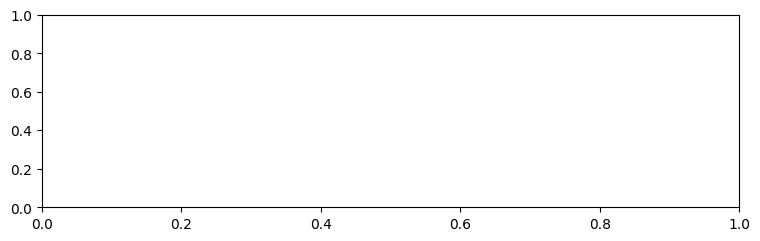

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from swc.aeon.qc import frame_rate_stability

if not camera_devices:
    print("No camera devices found in this dataset")
else:
    fig, axes = plt.subplots(
        len(camera_devices), 1,
        figsize=(9, 2.5 * len(camera_devices)),
        squeeze=False,
        sharex=False,
    )
    for ax, (device_name, cam_reader) in zip(axes[:, 0], camera_devices.items()):
        stats = frame_rate_stability(ROOT, cam_reader, start=START, end=END)
        if not stats.attrs.get("data_found", True):
            ax.set_title(f"{device_name}: NO DATA")
            ax.axis("off")
            continue
        median_ms = float(stats["interval_median_ms"].iloc[0])
        if not np.isfinite(median_ms):
            ax.set_title(f"{device_name}: no consecutive frames")
            ax.axis("off")
            continue
        bin_edges = stats.attrs["histogram_bin_edges_ms"]
        counts = stats.attrs["histogram_counts"]
        n_above = int(stats.attrs["histogram_n_above"])
        p99_ms = float(stats["interval_p99_ms"].iloc[0])
        max_ms = float(stats["interval_max_ms"].iloc[0])
        ax.bar(bin_edges[:-1], counts, width=np.diff(bin_edges), align="edge",
               color="steelblue", edgecolor="none")
        ax.axvline(median_ms, color="black", linestyle="--", linewidth=1,
                   label=f"median {median_ms:.2f} ms")
        ax.axvline(p99_ms, color="firebrick", linestyle=":", linewidth=1,
                   label=f"p99 {p99_ms:.2f} ms")
        ax.set_yscale("log")
        title = (f"{device_name}  (n={int(counts.sum()) + n_above:,}, "
                 f"max={max_ms:.2f} ms, fps~{1000/median_ms:.2f}")
        if n_above:
            title += f", {n_above} above {bin_edges[-1]:.1f} ms"
        title += ")"
        ax.set_title(title)
        ax.set_xlabel("inter-frame interval (ms)")
        ax.set_ylabel("count (log)")
        ax.legend(loc="upper right", fontsize=8)
    plt.tight_layout()
    plt.show()

## Harp gaps (continuous-rate streams)

Detects dropped samples in any continuous-rate Harp stream. The expected sample rate is read from `reader.expected_hz` (tagged on the reader instance by the Stream wrapper); bare `Encoder` readers fall back to 500 Hz inside `run_qc`.

Streams currently covered:

- Wheel encoder (~500 Hz) - `Patch*.Encoder` on social/exp02 schemas
- Photodiode (1 kHz, register 44) - octagon01
- VideoController camera-trigger (50 Hz, register 92) - octagon01

Only gaps longer than the threshold (default 1 s) are flagged, ignoring sub-second jitter. Returns a DataFrame indexed by gap-start time with `duration`, `n_missed`, and `device` columns.

In [ ]:
from swc.aeon.qc import harp_gaps
from swc.aeon.qc.harp import DEFAULT_THRESHOLD as HARP_THRESHOLD
from swc.aeon.io.reader import Encoder as EncoderReader, Harp as HarpReader

# Continuous-rate Harp readers: any Harp tagged with `.expected_hz`,
# plus bare Encoder (defaulted to 500 Hz to match run_qc dispatch).
harp_devices = {}
for name, reader in iter_readers(SCHEMA):
    if isinstance(reader, HarpReader) and hasattr(reader, "expected_hz"):
        harp_devices[name] = reader
    elif isinstance(reader, EncoderReader):
        reader.expected_hz = 500.0
        harp_devices[name] = reader

if not harp_devices:
    print("No continuous-rate Harp devices found in this dataset")
else:
    print(f"Found {len(harp_devices)} continuous Harp device(s):")
    for name, reader in harp_devices.items():
        print(f"  {name}: {reader.expected_hz} Hz")
    print(f"Gap threshold: {HARP_THRESHOLD}\n")
    for device_name, harp_reader in harp_devices.items():
        gaps = harp_gaps(ROOT, harp_reader, start=START, end=END)
        data_ok = gaps.attrs.get("data_found", True)
        if not data_ok:
            print(f"{device_name}: NO DATA")
        elif gaps.empty:
            print(f"{device_name}: 0 gap event(s)")
        else:
            total_missed = gaps["n_missed"].sum()
            print(f"{device_name}: {len(gaps)} gap event(s), {total_missed} total missed samples")
            display(gaps)

## Pellet delivery failures

Reports hardware-logged pellet delivery failures from the `MissedPellet` and
`RetriedDelivery` streams.
Returns a DataFrame indexed by event time with `outcome` (`missed` or `retried`)
and `device` columns.

In [ ]:
from swc.aeon.qc import pellet_failures
from swc.aeon.qc.report import iter_readers

feeder_devices = {}
for name, reader in iter_readers(SCHEMA):
    device, _, stream = name.partition(".")
    if stream in ("DeliverPellet", "MissedPellet", "RetriedDelivery"):
        feeder_devices.setdefault(device, {})[stream] = reader

feeder_devices = {d: s for d, s in feeder_devices.items() if "DeliverPellet" in s}

if not feeder_devices:
    print("No feeder devices found in schema")
else:
    for device_name, streams in feeder_devices.items():
        stats = pellet_failures(
            ROOT,
            deliver_reader=streams["DeliverPellet"],
            missed_reader=streams.get("MissedPellet"),
            retried_reader=streams.get("RetriedDelivery"),
            start=START, end=END,
        )
        n = stats.attrs.get("n_deliveries", 0)
        n_retried = stats.attrs.get("n_retried", 0)
        n_missed = stats.attrs.get("n_missed", 0)
        print(f"{device_name}: {n} deliveries, {n_retried} retried, {n_missed} missed")
        if not stats.empty:
            display(stats)

## Message log errors

Surfaces Warning and Error entries from the Bonsai message log.

In [ ]:
from swc.aeon.qc import message_log_errors
from swc.aeon.io.reader import Log as LogReader

log_readers = {name: reader for name, reader in iter_readers(SCHEMA)
               if isinstance(reader, LogReader)}

if not log_readers:
    print("No MessageLog readers found in schema")
else:
    for name, reader in log_readers.items():
        errors = message_log_errors(ROOT, reader, start=START, end=END)
        n_total = errors.attrs.get("n_total", 0)
        print(f"{name}: {n_total} total log entries, {len(errors)} non-Info")
        if not errors.empty:
            display(errors)

## Environment state

Shows time spent in each environment state (e.g. `Running`, `Maintenance`) over
the selected time range.

In [ ]:
from swc.aeon.qc import environment_state_durations
from swc.aeon.io.reader import Csv as CsvReader

env_state_readers = {name: reader for name, reader in iter_readers(SCHEMA)
                     if isinstance(reader, CsvReader) and "EnvironmentState" in name}

if not env_state_readers:
    print("No EnvironmentState readers found in schema")
else:
    for name, reader in env_state_readers.items():
        durations = environment_state_durations(ROOT, reader, start=START, end=END)
        if not durations.attrs.get("data_found", True):
            print(f"{name}: NO DATA")
        elif durations.empty:
            print(f"{name}: no state transitions found")
        else:
            totals = durations.groupby("state")["duration"].sum()
            print(f"{name}:")
            for state, total in totals.items():
                print(f"  {state}: {total}")

## Full scan

Runs all applicable QC checks across every stream in the schema at once.
Returns a dict of DataFrames keyed by device stream name. In addition to the
per-device metrics shown in the individual sections above, `run_qc` also
automatically includes `heartbeat_duplicates` (key: `<device>.duplicates`) and
`harp_sync_alerts` (key: `<device>.harp_sync_alerts`) for every Heartbeat and
MessageLog stream respectively.

In [ ]:
results = run_qc(ROOT, SCHEMA, start=START, end=END)

for name, df in results.items():
    found = df.attrs.get("data_found", True)
    status = "NO DATA" if not found else f"{len(df)} row(s)"
    print(f"{name}: {status}")

## Generate YAML report

Writes a structured YAML summary to disk with per-device `summary` and `detail` sections.
Also saves the full results dict as a pickle for downstream analysis.

In [ ]:
import os

os.makedirs("qc_results", exist_ok=True)

output = generate_report(ROOT, results, "qc_results/qc_report.yaml", start=START, end=END)
print(f"Report written to {output}")

pkl = save_results(results, "qc_results/qc_results.pkl")
print(f"Results pickled to {pkl}")

### Debug: inspect heartbeat data around a specific timestamp

In [ ]:
from swc.aeon.io import api as aeon_api

t = pd.Timestamp("2024-01-31T11:28:45", tz="UTC")
w = pd.Timedelta("10seconds")

frames = {}
for name, reader in hb_devices.items():
    df = aeon_api.load(ROOT, reader, start=t - w, end=t + w)
    if not df.empty:
        frames[name] = df["second"].astype(int).rename(name)

combined = pd.concat(frames.values(), axis=1, join="outer").sort_index()
display(combined)

## Octagon QC example

Octagon datasets use a self-contained schema: each epoch directory is a separate session, not a chunk of a continuous experiment. The cleanest way to QC an octagon session is to pass the **epoch directory itself** as the load root, so `load()` cannot pick up chunks from neighbouring sessions. `derive_epoch_window` reads the chunk filenames inside the directory to give the natural load window.

The octagon01 schema covers:

- `CameraTop` and `CameraColorTop` (Video, 50 fps and 60 fps respectively) - dropped frames + frame rate stability
- `Photodiode` (Harp register 44, 1 kHz, columns `adc`+`encoder`) - `harp_gaps`
- `VideoController` (Harp register 92, 50 Hz, camera trigger pulses) - `harp_gaps`

No heartbeats are saved on this rig, so heartbeat / sync_delta / harp_sync_alerts metrics produce nothing for octagon. The TaskLogic / Wall / OSC event streams have no QC dispatch yet (event counts would be the natural next step).

In [ ]:
from pathlib import Path
from swc.aeon.qc.schemas import REGISTRY, derive_epoch_window

OCTAGON_ROOT = Path(r"Z:\aeon\data\raw\OCTAGON01\conf1\2023-02-17T15-53-21")
OCTAGON_START = pd.Timestamp("2023-02-17T15:53:21", tz="UTC")
_, OCTAGON_END = derive_epoch_window(OCTAGON_ROOT)

octagon_results = run_qc(
    str(OCTAGON_ROOT),
    REGISTRY["octagon01"],
    start=OCTAGON_START,
    end=OCTAGON_END,
)

rows = []
for name, df in octagon_results.items():
    found = df.attrs.get("data_found", True)
    n_samples = df.attrs.get("n_samples") or df.attrs.get("n_frames")
    expected_hz = df.attrs.get("expected_hz")
    metric = df.attrs.get("metric", "")
    if not found:
        status = "NO DATA"
    elif df.empty:
        status = "0 events"
    else:
        status = f"{len(df)} row(s)"
    rows.append({
        "stream": name,
        "metric": metric,
        "expected_hz": expected_hz,
        "n_samples": n_samples,
        "status": status,
    })

octagon_df = pd.DataFrame(rows).set_index("stream")
display(octagon_df)